# **Question 5**

Implement 2D Image registration b/w two images using feature matching.Implement affine transformations on an image . Recognize an object in a scene using local feature matching.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


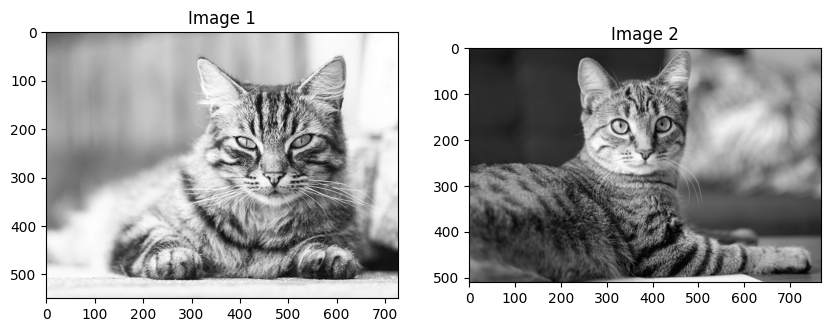

In [12]:
img1 = cv2.imread("image1.jpg", cv2.IMREAD_GRAYSCALE)   # reference image
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)   # image to align

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image 1")
plt.imshow(img1, cmap='gray')

plt.subplot(1,2,2)
plt.title("Image 2")
plt.imshow(img2, cmap='gray')

plt.show()


In [14]:
# PART 1: 2D Image Registration using Feature Matching
# Detect Keypoints and Descriptors
orb = cv2.ORB_create(5000)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print("Keypoints in Image1:", len(kp1))
print("Keypoints in Image2:", len(kp2))


Keypoints in Image1: 5000
Keypoints in Image2: 4909


In [15]:
# Feature Matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches:", len(matches))

Total Matches: 1131


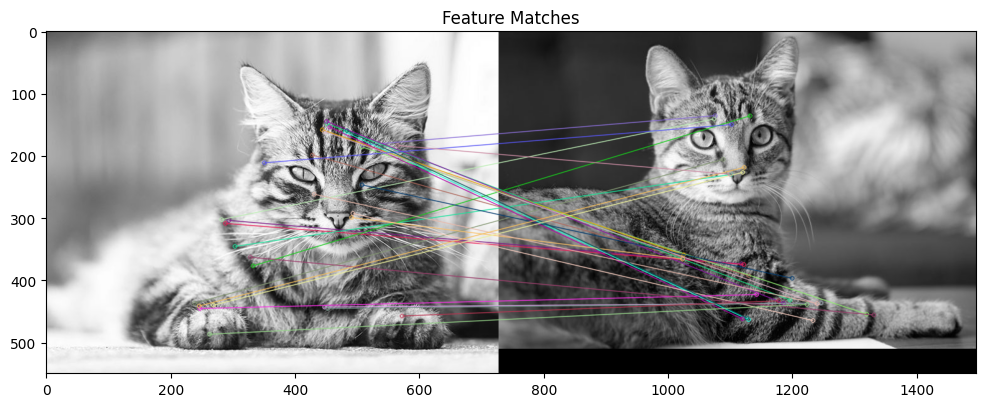

In [16]:
# Draw Matches
match_img = cv2.drawMatches(img1, kp1, img2, kp2,
                            matches[:30], None,
                            flags=2)

plt.figure(figsize=(12,6))
plt.imshow(match_img)
plt.title("Feature Matches")
plt.show()


In [17]:
# Estimate Transformation (Homography)
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC)

print("Homography Matrix:\n", H)

Homography Matrix:
 [[ 3.84516252e+00 -5.27467798e+00  4.70559735e+02]
 [ 2.63831825e+00 -3.57522168e+00  3.04011846e+02]
 [ 8.21147049e-03 -1.12498085e-02  1.00000000e+00]]


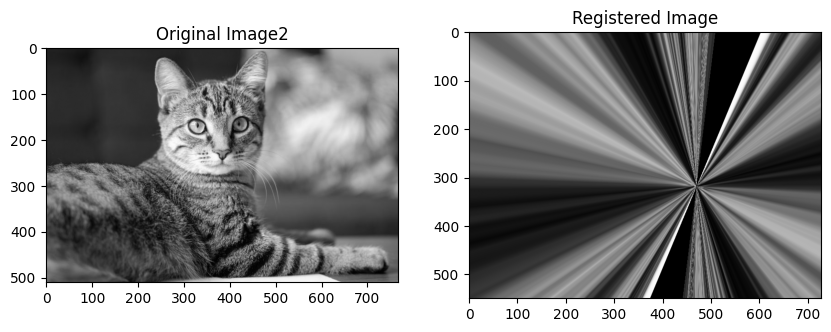

In [18]:
# Register Image
h, w = img1.shape

registered = cv2.warpPerspective(img2, H, (w, h))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image2")
plt.imshow(img2, cmap='gray')

plt.subplot(1,2,2)
plt.title("Registered Image")
plt.imshow(registered, cmap='gray')

plt.show()


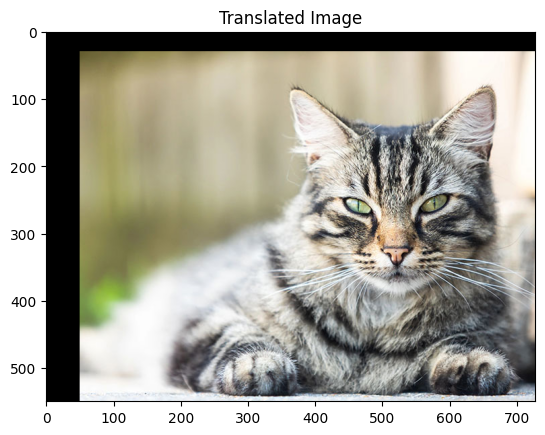

In [26]:
# PART 2: Affine Transformation
# Affine Transformation
img = cv2.imread("image1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Translation

rows, cols = img.shape[:2]

tx, ty = 50, 30

M = np.float32([[1,0,tx],
                [0,1,ty]])

translated = cv2.warpAffine(img, M, (cols, rows))

plt.imshow(translated)
plt.title("Translated Image")
plt.show()


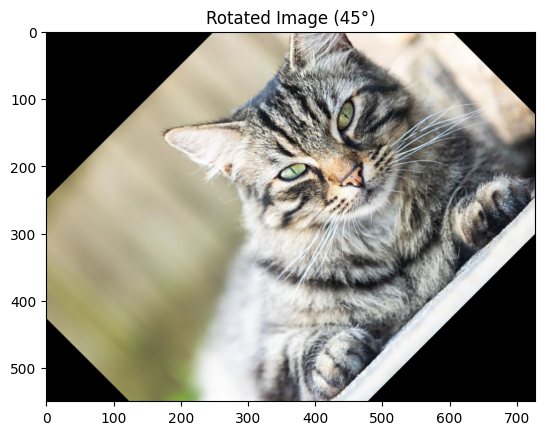

In [27]:
# Rotation
center = (cols//2, rows//2)

M = cv2.getRotationMatrix2D(center, 45, 1)

rotated = cv2.warpAffine(img, M, (cols, rows))

plt.imshow(rotated)
plt.title("Rotated Image (45°)")
plt.show()

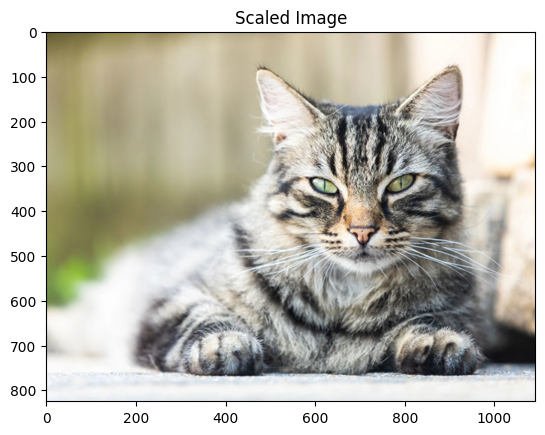

In [28]:
# Scaling
scaled = cv2.resize(img, None, fx=1.5, fy=1.5)

plt.imshow(scaled)
plt.title("Scaled Image")
plt.show()


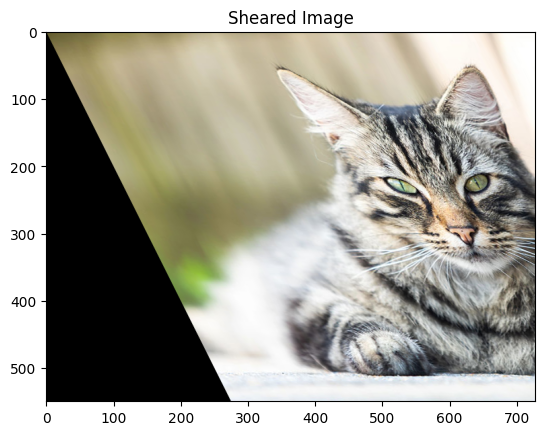

In [29]:
# Shearing
M = np.float32([[1,0.5,0],
                [0,1,0]])

sheared = cv2.warpAffine(img, M, (cols, rows))

plt.imshow(sheared)
plt.title("Sheared Image")
plt.show()

In [37]:
from google.colab import files

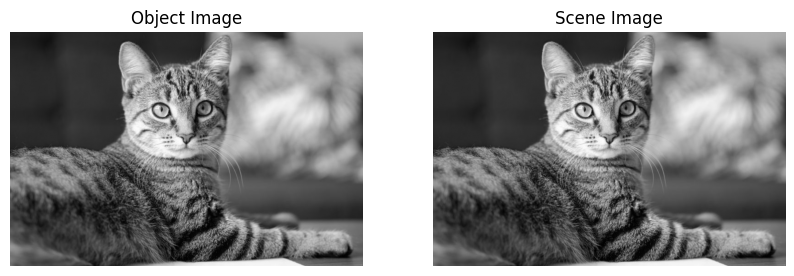

In [48]:
# PART 3: Object Recognition using Local Feature Matching
# Load Object and Scene
object_img = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)
scene_img = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Object Image")
plt.imshow(object_img, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Scene Image")
plt.imshow(scene_img, cmap='gray')
plt.axis("off")

plt.show()


In [49]:
# Detect Local Features
orb = cv2.ORB_create(3000)

kp_obj, des_obj = orb.detectAndCompute(object_img, None)
kp_scene, des_scene = orb.detectAndCompute(scene_img, None)

print("Object Keypoints:", len(kp_obj))
print("Scene Keypoints:", len(kp_scene))


Object Keypoints: 3000
Scene Keypoints: 3000


In [50]:
# Feature Matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des_obj, des_scene, k=2)

good = []

for m,n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Good Matches:", len(good))

Good Matches: 3000


(np.float64(-0.5), np.float64(1535.5), np.float64(510.5), np.float64(-0.5))

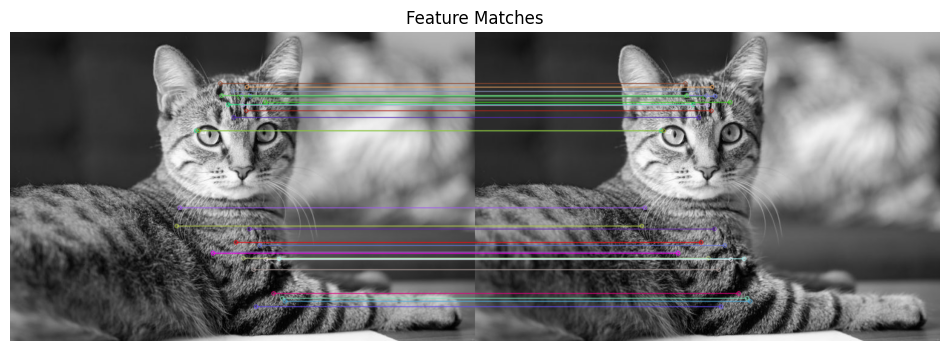

In [51]:
# Draw feature matches
match_img = cv2.drawMatches(object_img, kp_obj,
                            scene_img, kp_scene,
                            good[:30], None, flags=2)

plt.figure(figsize=(12,6))
plt.title("Feature Matches")
plt.imshow(match_img)
plt.axis("off")


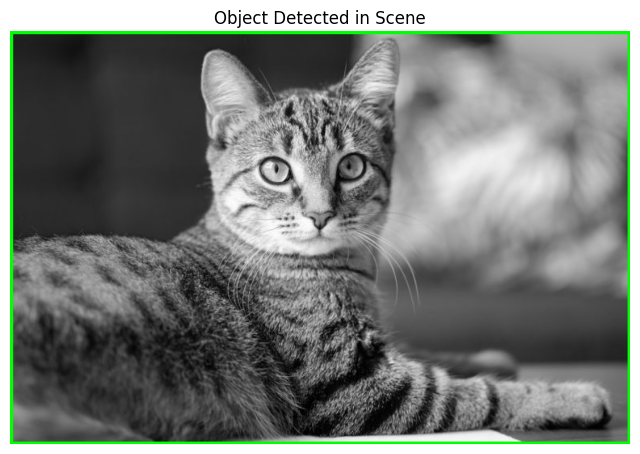

In [52]:
# Detect object in scene
if len(good) > 10:

    src_pts = np.float32([kp_obj[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    h,w = object_img.shape

    pts = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)

    dst = cv2.perspectiveTransform(pts,H)

    scene_color = cv2.cvtColor(scene_img, cv2.COLOR_GRAY2BGR)

    detected = cv2.polylines(scene_color,
                             [np.int32(dst)],
                             True,(0,255,0),5)

    plt.figure(figsize=(8,6))
    plt.title("Object Detected in Scene")
    plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
    plt.axis("off")

else:
    print("Not enough matches found")
